In [4]:
import torch
import torch.nn as nn
from torch.nn import Linear
import torch.nn.functional as F
import torch_geometric
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import (
  to_dense_adj, to_networkx, degree
)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import random
import warnings


warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")

Zachary's Karate Club: https://networks.skewed.de/net/karate

In [5]:
# Load Zachary's Karate Club graph
G = nx.karate_club_graph()

print(f"Number of nodes: {G.number_of_nodes()}")

Number of nodes: 34


In [6]:
print(f"Number of edges: {G.number_of_edges()}")

Number of edges: 78


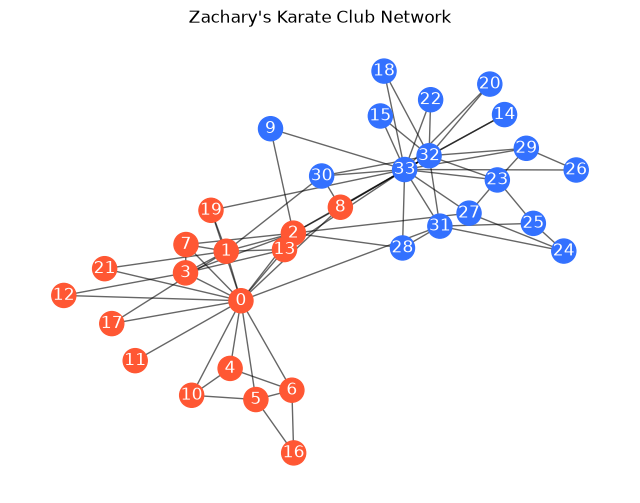

In [7]:
# Get the club membership attribute for coloring
club_labels = [G.nodes[i]['club'] for i in G.nodes]

# Color based on club membership ('Mr. Hi' or 'Officer')
color_map = [
  '#FF5733' if club == 'Mr. Hi' else '#3371FF' for club in club_labels
  ]

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G) # positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=color_map)
nx.draw_networkx_edges(G, pos, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_color='white')

plt.title("Zachary's Karate Club Network")
plt.axis('off')
plt.show()

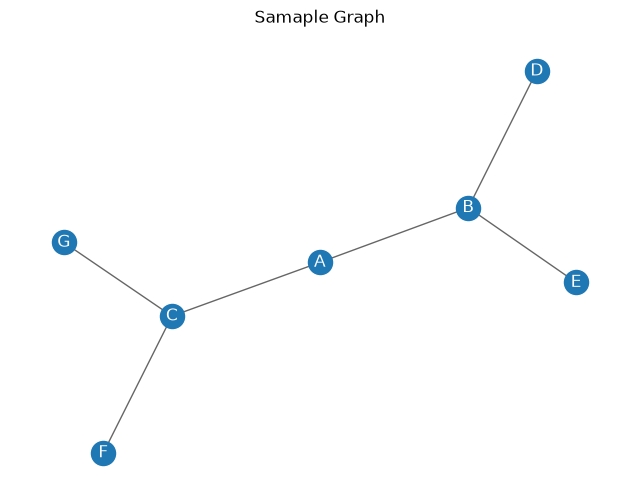

In [9]:
G = nx.Graph()
G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'D'),
('B', 'E'), ('C', 'F'), ('C', 'G')])

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G) # positions for all nodes
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_edges(G, pos, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_color='white')

plt.title("Samaple Graph")
plt.axis('off')
plt.show()

In [10]:
print(f"deg(A) = {G.degree['A']}")

deg(A) = 2


In [11]:
print(f"deg(B) = {G.degree['B']}")

deg(B) = 3


# Cora Example

Cora Dataset: https://graphsandnetworks.com/the-cora-dataset/

![CoraBalloons](../images/CoraBalloons.png)

| # | Atributo                   | Valor                                                  |
|---|----------------------------|--------------------------------------------------------|
| 1 | Nodos                      | 2,708 (Artículos científicos)                          |
| 2 | Aristas                    | 10,556 (Citas)                                         |
| 3 | Características (Features) | 1,433 (Vector binario de palabras clave, Bag-of-Words) |
| 4 | Clases                     | 7 categorías de investigación                          |

| Categoria | Nombre                 | Descripción                                                              |
|-----------|------------------------|--------------------------------------------------------------------------|
| 0         | Theory                 | Aspectos teóricos, algoritmos fundamentales y pruebas matemáticas.       |
| 1         | Reinforcement Learning | Agentes que aprenden mediante prueba y error para maximizar recompensas. |
| 2         | Genetic Algorithms     | Algoritmos de optimización inspirados en la evolución biológica.         |
| 3         | Neural Networks        | Modelos basados en capas de neuronas artificiales y Deep Learning.       |
| 4         | Probabilistic Methods  | Modelos que gestionan la incertidumbre (Redes Bayesianas, etc.).         |
| 5         | Case Based             | Sistemas de razonamiento basados en casos y analogías previas.           |

In [13]:
dataset = Planetoid(root='../data/', name='cora')
data = dataset[0]

Processing...
Done!


In [18]:
cora_features = pd.DataFrame(dataset.x.numpy(),columns=["word"+str(i) for i in range(1433)])
cora_features["category"] = data.y

cora_features[cora_features.columns[-10:]].head(20)

,word1424,word1425,word1426,word1427,word1428,word1429,word1430,word1431,word1432,category
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
8,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [15]:
class GraphUtils:
    @staticmethod
    def create_adjacency_matrix(data):
        # Crea matriz de adyacencia
        adjacency = to_dense_adj(data.edge_index)[0]
        # Agrega una diagonal de unos (auto-referencia a nodos)
        adjacency = adjacency + torch.eye(len(adjacency))
        return adjacency

    @staticmethod
    def convert_to_networkx(graph, n_sample=None):
        g = to_networkx(graph, node_attrs=["x"])
        y = graph.y.numpy()
    
        if n_sample is not None:
            sampled_nodes  = random.sample(list(g.nodes), n_sample)
            g = g.subgraph(sampled_nodes)
            y = y[sampled_nodes]
    
        return g, y
    
    @staticmethod
    def plot_graph(g, y):
        plt.figure(figsize=(9, 7))
        nx.draw_spring(g, node_size=30, arrows=False, node_color=y)
        plt.show() 

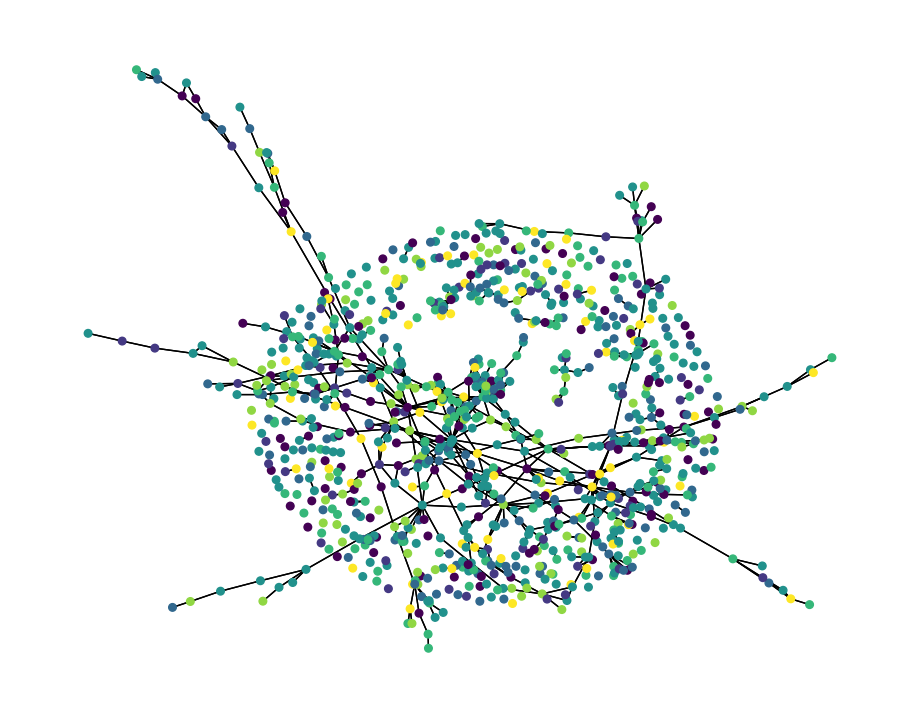

In [19]:
g, y = GraphUtils.convert_to_networkx(data, n_sample=1000)
GraphUtils.plot_graph(g, y)  

## A. Multilayer Percepton en las features tabulares de Cora

In [20]:
class MLP(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs, learning_rate=0.01, weight_decay=5e-4):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate, weight_decay=weight_decay)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = self.accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = self.accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = self.accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

    @staticmethod
    def accuracy(y_pred, y_true):
        return torch.sum(y_pred == y_true).item() / len(y_true)

In [23]:
class GNNLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x

In [24]:
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)

MLP(
  (linear1): Linear(in_features=1433, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=7, bias=True)
)


# B. Modelo basado en una capa lineal que se multiplica por la matriz de adyacencia

In [22]:
class GNN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = GNNLayer(dim_in, dim_h)
        self.gnn2 = GNNLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, adjacency, epochs, learning_rate=0.01, weight_decay=5e-4):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate, weight_decay=weight_decay)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = MLP.accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = MLP.accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data, adjacency):
        self.eval()
        out = self(data.x, adjacency)
        acc = MLP.accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [25]:
adjacency = GraphUtils.create_adjacency_matrix(data)
gnn = GNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)

GNN(
  (gnn1): GNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=False)
  )
  (gnn2): GNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=False)
  )
)


# Entrenamos ambos modelos
### Tranining MLP

In [26]:
mlp.fit(data, epochs=100)

Epoch   0 | Train Loss: 1.951 | Train Acc: 14.29% | Val Loss: 1.95 | Val Acc: 16.20%
Epoch  20 | Train Loss: 0.103 | Train Acc: 100.00% | Val Loss: 1.33 | Val Acc: 55.80%
Epoch  40 | Train Loss: 0.012 | Train Acc: 100.00% | Val Loss: 1.41 | Val Acc: 54.00%
Epoch  60 | Train Loss: 0.007 | Train Acc: 100.00% | Val Loss: 1.40 | Val Acc: 54.40%
Epoch  80 | Train Loss: 0.008 | Train Acc: 100.00% | Val Loss: 1.33 | Val Acc: 55.00%
Epoch 100 | Train Loss: 0.009 | Train Acc: 100.00% | Val Loss: 1.31 | Val Acc: 56.40%


In [27]:
acc_mlp = mlp.test(data)
print(f'\nMLP test accuracy: {acc_mlp*100:.2f}%')


MLP test accuracy: 55.40%


# Training GNN

In [28]:
gnn.fit(data, adjacency, epochs=100)

Epoch   0 | Train Loss: 2.250 | Train Acc: 10.71% | Val Loss: 2.25 | Val Acc: 14.60%
Epoch  20 | Train Loss: 0.216 | Train Acc: 96.43% | Val Loss: 1.40 | Val Acc: 70.80%
Epoch  40 | Train Loss: 0.045 | Train Acc: 100.00% | Val Loss: 1.68 | Val Acc: 74.80%
Epoch  60 | Train Loss: 0.011 | Train Acc: 100.00% | Val Loss: 1.94 | Val Acc: 75.60%
Epoch  80 | Train Loss: 0.004 | Train Acc: 100.00% | Val Loss: 2.06 | Val Acc: 73.80%
Epoch 100 | Train Loss: 0.003 | Train Acc: 100.00% | Val Loss: 2.08 | Val Acc: 73.80%


In [29]:
acc_gnn = gnn.test(data, adjacency)

print(f'\nGNN test accuracy: {acc_gnn*100:.2f}%')


GNN test accuracy: 75.20%


In [30]:
pd.DataFrame(
  {
    "modelo": ["MLP", "GNN"],
    "accuracy": [acc_mlp*100, acc_gnn*100]
  }
)

,modelo,accuracy
0,MLP,55.4
1,GNN,75.2


## ¿Qué están haciendo las Graph Neural Networks?

In [32]:
from torch_geometric.datasets import KarateClub

# Import dataset from PyTorch Geometric
dataset = KarateClub()
data = dataset[0]

In [34]:
# Print information
print(f'Number of graphs: {len(dataset)}')

Number of graphs: 1


In [35]:
print(f'Number of features: {dataset.num_features}')

Number of features: 34


In [36]:
print(f'Number of classes: {dataset.num_classes}')

Number of classes: 4


In [37]:
print(f'x = {data.x.shape}')

x = torch.Size([34, 34])


In [38]:
print(data.x)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])


In [39]:
print(f'edge_index = {data.edge_index.shape}')

edge_index = torch.Size([2, 156])


In [41]:
pd.DataFrame(data.x, columns=["x"+str(i+1) for i in range(data.x.shape[0])]).head(10)

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


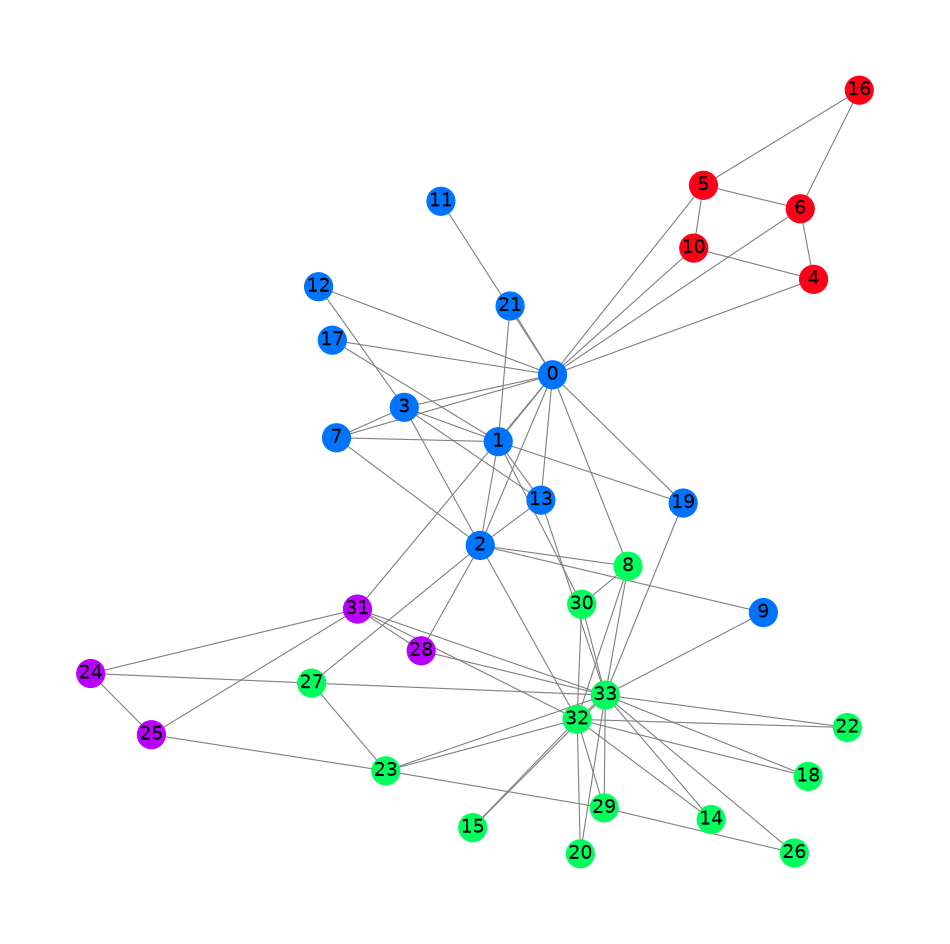

In [43]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')

nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=True,
                node_size=400,
                node_color=data.y,
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.8,
                edge_color="grey",
                font_size=14
                )
plt.show()

In [45]:
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn = GCNConv(dataset.num_features, 3)
        self.out = Linear(3, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.gcn(x, edge_index).relu()
        z = self.out(h)
        return h, z

In [91]:
# Definimos el modelo 
model = GCN()
print(model)

GCN(
  (gcn): GCNConv(34, 3)
  (out): Linear(in_features=3, out_features=4, bias=True)
)


In [92]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-2)

embeddings = []
losses = []
accuracies = []
outputs = []

# Training loop
for epoch in range(201):
    model.train()
    optimizer.zero_grad()

    # Forward pass (El modelo devuelve h primero, luego z)
    h, z = model(data.x, data.edge_index)

    # Calcular la pérdida usando la máscara de entrenamiento (esencial en KarateClub)
    loss = criterion(z[data.train_mask], data.y[data.train_mask])

    # Calcular el accuracy (usando la máscara de entrenamiento o general según prefieras)
    acc = accuracy(z[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    # Guardar los datos limpios para usar después en la celda del t-SNE
    embeddings.append(h.detach().cpu())
    losses.append(loss.item())
    accuracies.append(acc.item())
    outputs.append(z.argmax(dim=1).detach().cpu())

    # Print metrics every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%')

Epoch   0 | Loss: 1.40 | Acc: 25.00%
Epoch  10 | Loss: 1.33 | Acc: 75.00%
Epoch  20 | Loss: 1.26 | Acc: 50.00%
Epoch  30 | Loss: 1.17 | Acc: 75.00%
Epoch  40 | Loss: 1.07 | Acc: 75.00%
Epoch  50 | Loss: 0.96 | Acc: 75.00%
Epoch  60 | Loss: 0.84 | Acc: 75.00%
Epoch  70 | Loss: 0.74 | Acc: 75.00%
Epoch  80 | Loss: 0.65 | Acc: 75.00%
Epoch  90 | Loss: 0.59 | Acc: 100.00%
Epoch 100 | Loss: 0.55 | Acc: 100.00%
Epoch 110 | Loss: 0.52 | Acc: 75.00%
Epoch 120 | Loss: 0.48 | Acc: 75.00%
Epoch 130 | Loss: 0.44 | Acc: 100.00%
Epoch 140 | Loss: 0.37 | Acc: 100.00%
Epoch 150 | Loss: 0.30 | Acc: 100.00%
Epoch 160 | Loss: 0.25 | Acc: 100.00%
Epoch 170 | Loss: 0.21 | Acc: 100.00%
Epoch 180 | Loss: 0.19 | Acc: 100.00%
Epoch 190 | Loss: 0.18 | Acc: 100.00%
Epoch 200 | Loss: 0.17 | Acc: 100.00%


In [93]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import torch

def plot_karate_tsne(embeddings_list, outputs_list, epoch):
    """
    Grafica los embeddings de una época específica usando t-SNE de forma minimalista.
    """
    emb = embeddings_list[epoch]
    pred = outputs_list[epoch]
    
    # Reducción de dimensiones
    tsne = TSNE(n_components=2, perplexity=5, random_state=123)
    emb_2d = tsne.fit_transform(emb.numpy())
    
    # Configuración de la figura limpia (sin bordes de gráfico)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.axis('off')  # Remueve por completo los ejes y recuadros exteriores
    
    # Dibujar los nodos más pequeños (s=120) y SIN bordes (linewidths=0)
    scatter = ax.scatter(
        emb_2d[:, 0], 
        emb_2d[:, 1], 
        c=pred.numpy(), 
        s=120,          # Tamaño reducido y elegante
        cmap="Set2",    # Paleta de colores suave
        alpha=0.85,     # Ligera transparencia para diseño moderno
        linewidths=0    # Cero bordes oscuros
    )
    
    # Dibujar los números sutilmente arriba o al centro de cada punto
    for i in range(emb_2d.shape[0]):
        ax.text(
            emb_2d[i, 0], 
            emb_2d[i, 1] + 0.1,  # Un pequeño offset vertical para que no tape el punto
            str(i), 
            color='#4A4A4A',     # Gris oscuro en lugar de negro puro (más estético)
            fontsize=8, 
            ha='center', 
            va='bottom'
        )
        
    plt.title(f"Época {epoch}", fontsize=12, color='#333333', pad=10)
    plt.show()

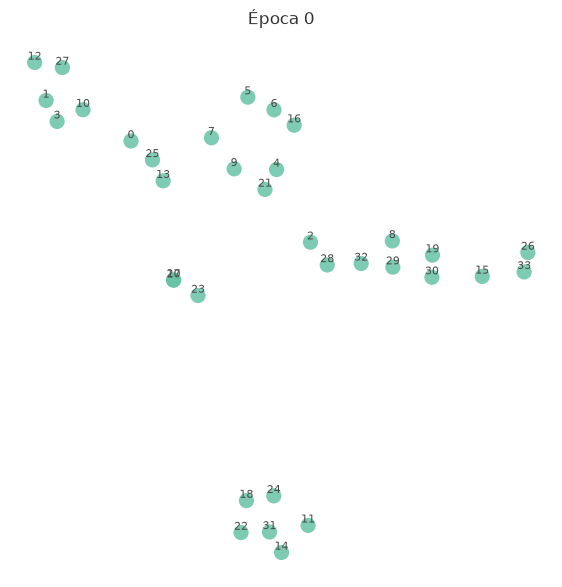

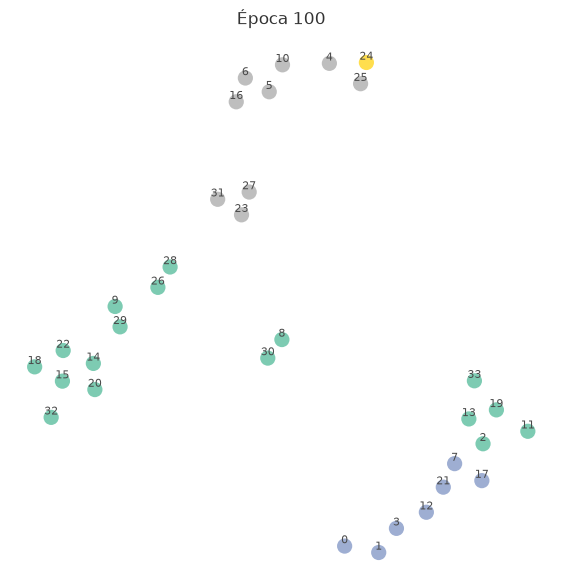

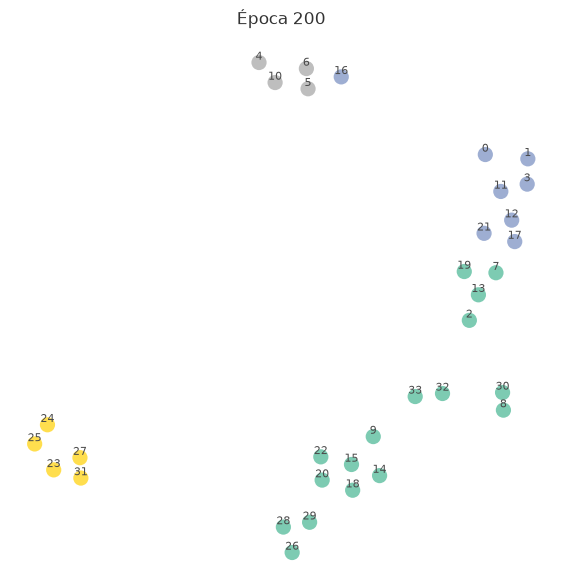

In [94]:
plot_karate_tsne(embeddings, outputs, epoch=0)
plot_karate_tsne(embeddings, outputs, epoch=100)
plot_karate_tsne(embeddings, outputs, epoch=200)

In [95]:
plt.rcParams["animation.bitrate"] = 3000

def draw_predicted_graph(i):
    G = to_networkx(data, to_undirected=True)
    fig = plt.figure(figsize=(12, 12))
    plt.axis('off')
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=True,
                    node_size=300,
                    node_color=outputs[i].numpy(),
                    cmap="hsv",
                    vmin=0,
                    vmax=5,
                    width=0.8,
                    edge_color="grey",
                    font_size=14
                    )
    plt.title(
      f'Epoch {i} | Loss: {losses[i]:.2f} | Acc: {accuracies[i]*100:.2f}%',
      fontsize=18, pad=20)
    plt.show()

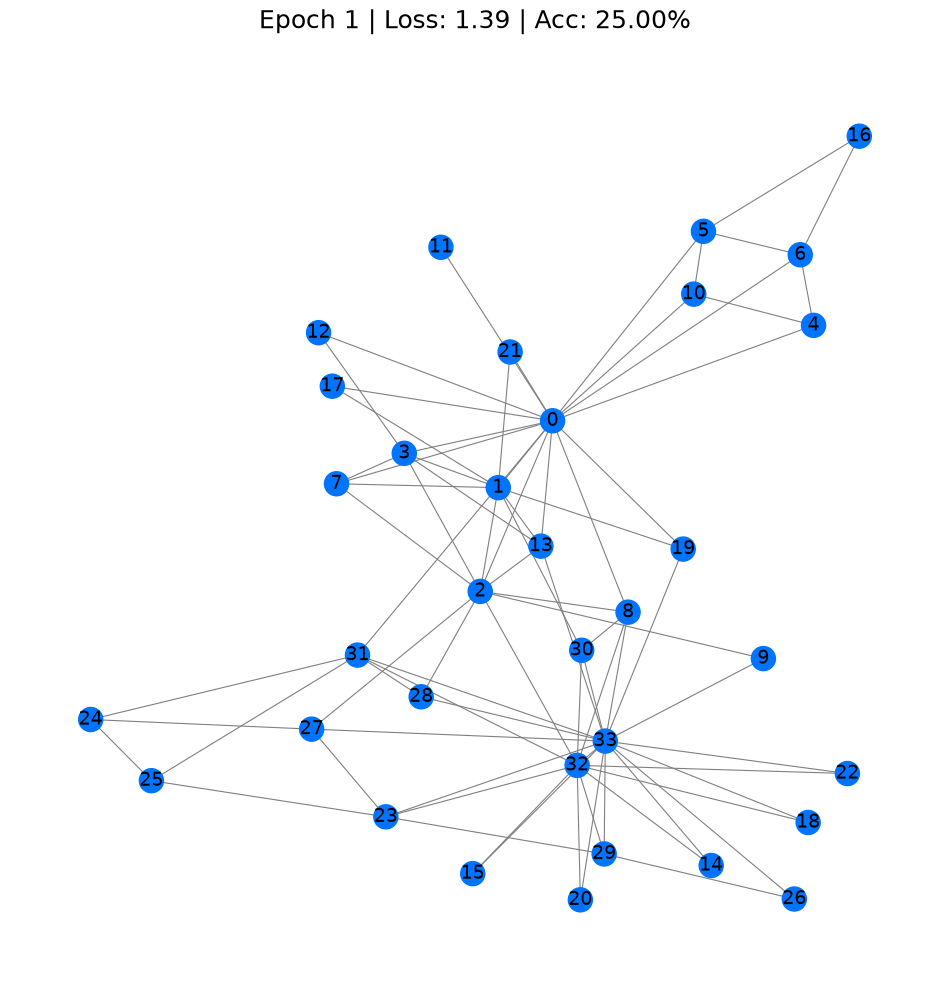

In [96]:
draw_predicted_graph(1)

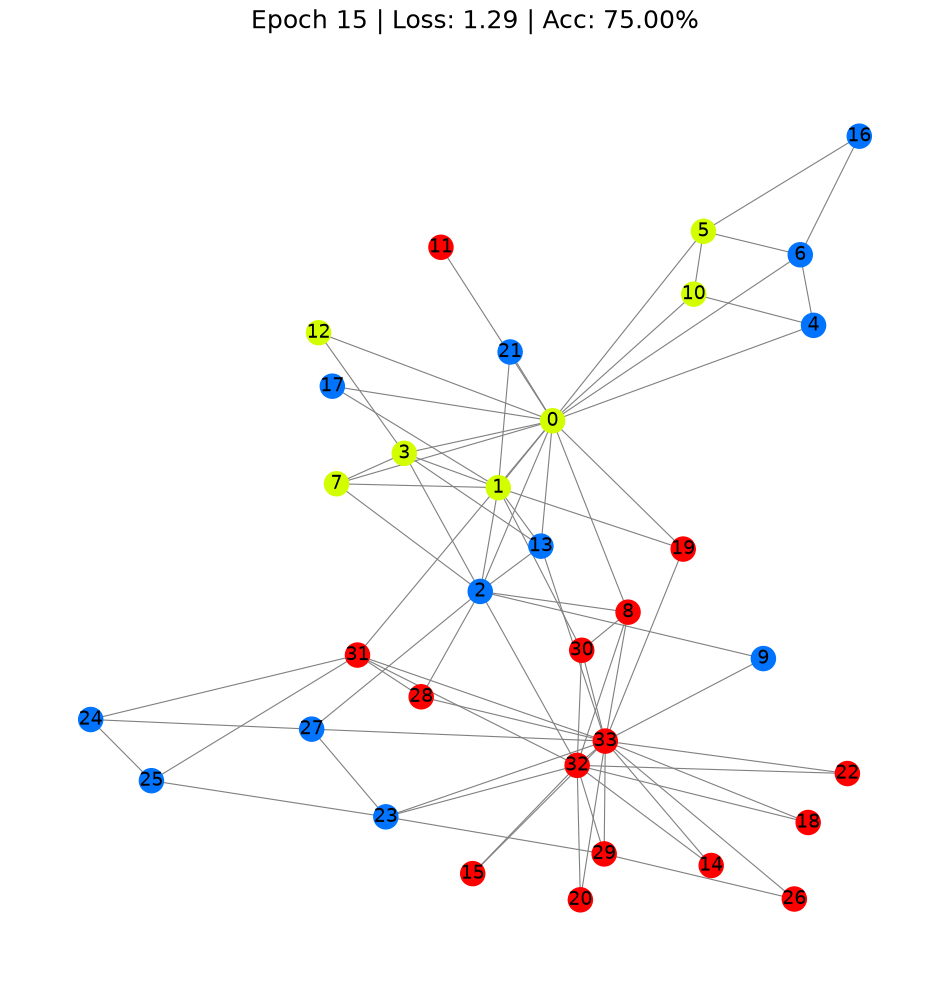

In [97]:
draw_predicted_graph(15)

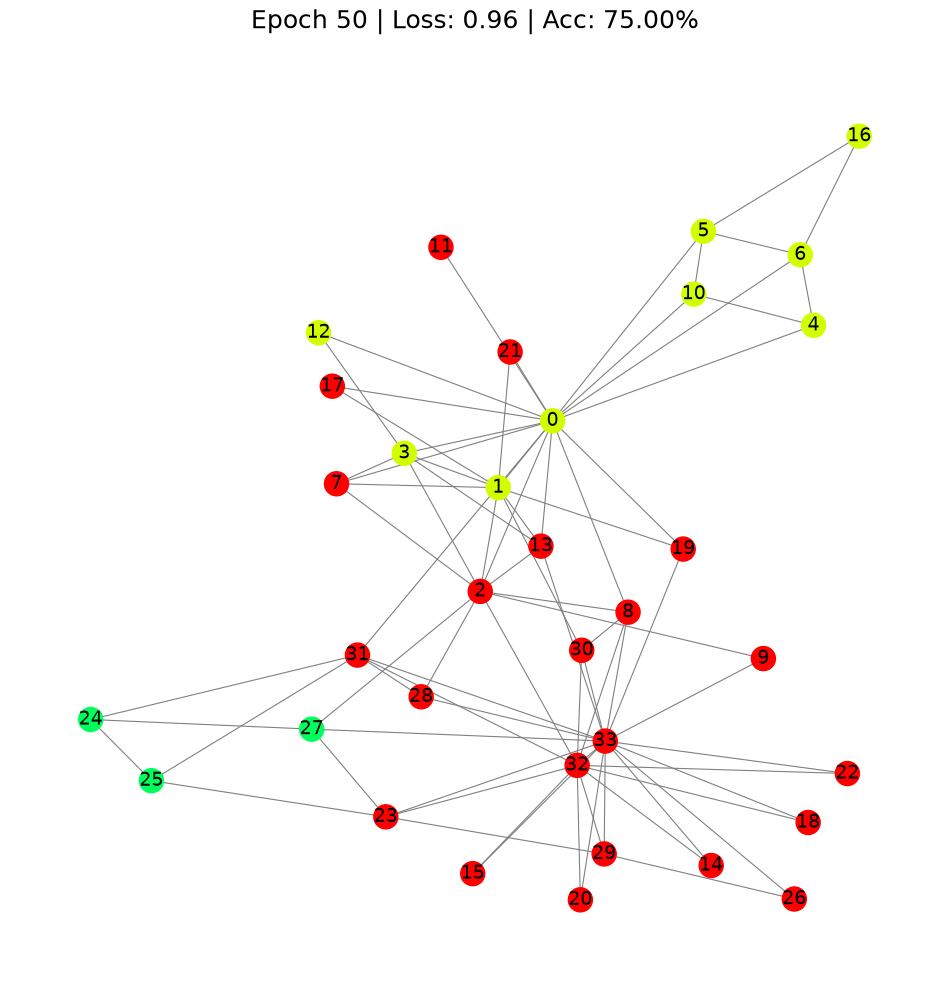

In [98]:
draw_predicted_graph(50)

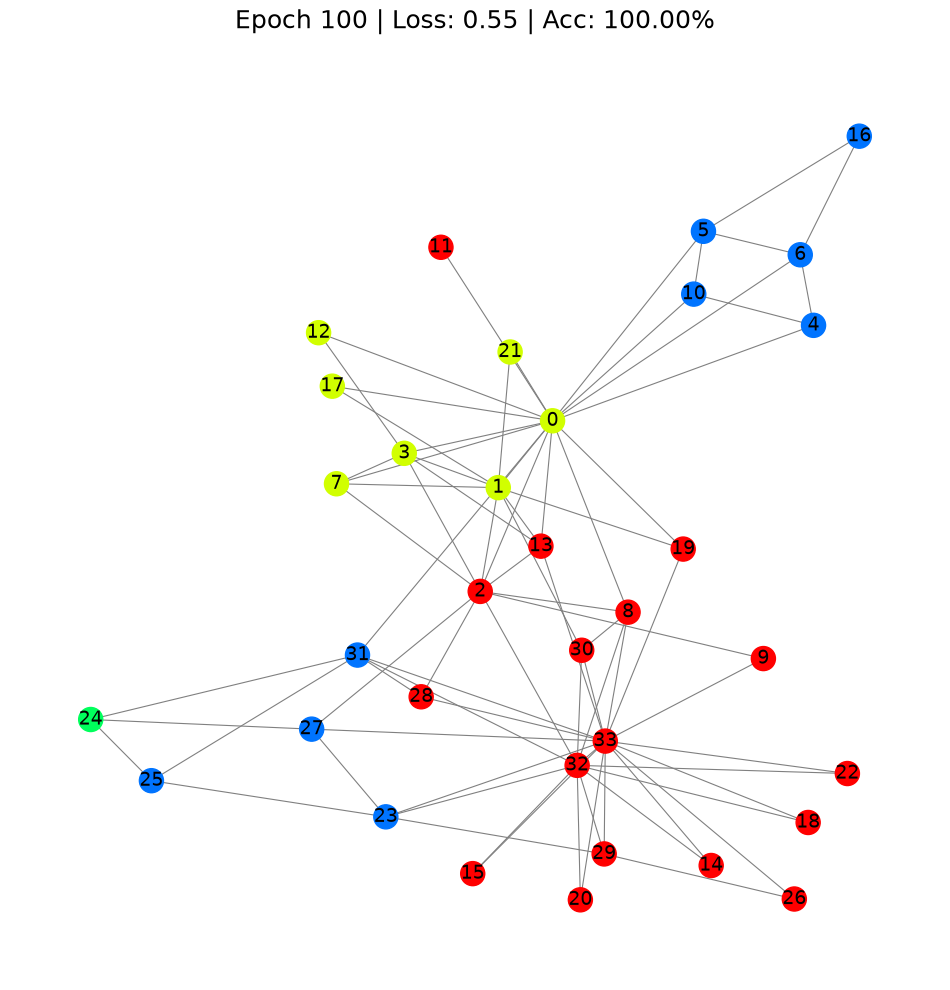

In [99]:
draw_predicted_graph(100)

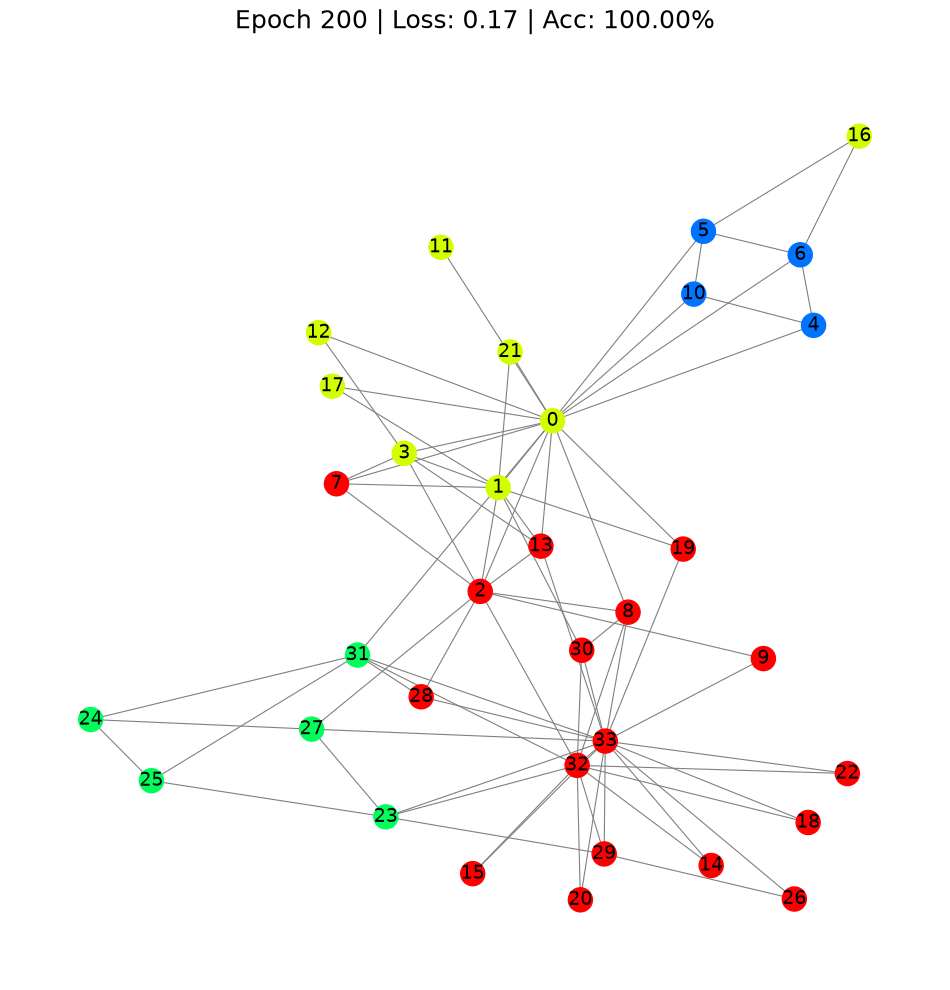

In [100]:
draw_predicted_graph(200)